In [ ]:
# --- project bootstrap ---
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
os.chdir(ROOT)
# -------------------------


In [ ]:
import os
import multiprocessing as mp

cpu_cap = 40
cpu_count = mp.cpu_count()
cpu_use = min(cpu_cap, cpu_count)
os.environ["MY_CPU_COUNT"] = str(cpu_use)
os.environ["OMP_NUM_THREADS"] = str(cpu_use)
os.environ["OPENBLAS_NUM_THREADS"] = str(cpu_use)
os.environ["MKL_NUM_THREADS"] = str(cpu_use)
os.environ["NUMEXPR_MAX_THREADS"] = str(cpu_use)
try:

    os.sched_setaffinity(0, set(range(20, 20+cpu_use)))
except Exception as exc:
    print(f"CPU affinity not set: {exc}")


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import fgtn.classA_U1FGTN as classA_U1FGTN
importlib.reload(classA_U1FGTN)
from fgtn.classA_U1FGTN import classA_U1FGTN

DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initiali

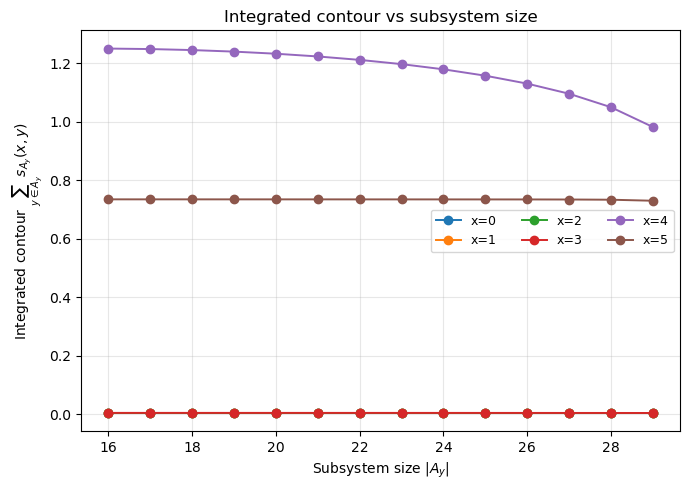

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from fgtn.classA_U1FGTN import classA_U1FGTN
# ---- User inputs ----
Nx, Ny = 12, 31
alpha_1, alpha_2 = 30, 1
periodic = True
x_list = np.arange(Nx // 2)
# ---------------------

def integrated_contour_for_size(model, G_gs, y_cut):
    # Tracing out (y_cut+1)*Nx sites, y_cut in [1, Ny-1])]
    yA = np.arange(y_cut, model.Ny)
    xA = np.arange(model.Nx)

    # Build flattened indices i = μ + 2*x + 2*Nx*y
    sub_indices = []
    for y in yA:
        for x in xA:
            sub_indices.append(0 + 2*x + 2*model.Nx*y)
            sub_indices.append(1 + 2*x + 2*model.Nx*y)
    sub_indices = np.array(sub_indices, dtype=int)

    # Reduced covariance
    G_sub = G_gs[np.ix_(sub_indices, sub_indices)]

    # Entanglement contour on the subsystem
    contour_helper = classA_U1FGTN(model.Nx, len(yA), DW=False, alpha_1=1, alpha_2=1)
    s_map = contour_helper.entanglement_contour(G_sub, len(xA), len(yA))  # shape: (Nx, Ay_size)

    # Integrated contour over y for each x
    return np.sum(s_map, axis=1)

# Build model and GS covariance with domain wall
model = classA_U1FGTN(Nx, Ny, DW=True, alpha_1=alpha_1, alpha_2=alpha_2)
G_gs = model.G_CI_domain_wall(periodic=periodic)

# Sweep A_y sizes and collect curves
y_cut_list = np.arange(2, Ny//2+1)  # |A_y| from 1..Ny-1
A_y_list = Ny-y_cut_list
Sx_vs_y_cut = {x: [] for x in x_list}

for y_cut in y_cut_list:
    Sx = integrated_contour_for_size(model, G_gs, y_cut)
    for x in x_list:
        Sx_vs_y_cut[x].append(Sx[x])

# Plot: integrated contour vs |A_y| for each x
plt.figure(figsize=(7, 5))
for x in x_list:
    curve = np.array(Sx_vs_y_cut[x])
    plt.plot(A_y_list, curve, marker='o', lw=1.4, label=f"x={x}")

plt.xlabel(r"Subsystem size $|A_y|$")
plt.ylabel(r"Integrated contour $\sum_{y \in A_y} s_{A_y}(x,y)$")
plt.title("Integrated contour vs subsystem size")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend(ncol=3, fontsize=9)
plt.show()


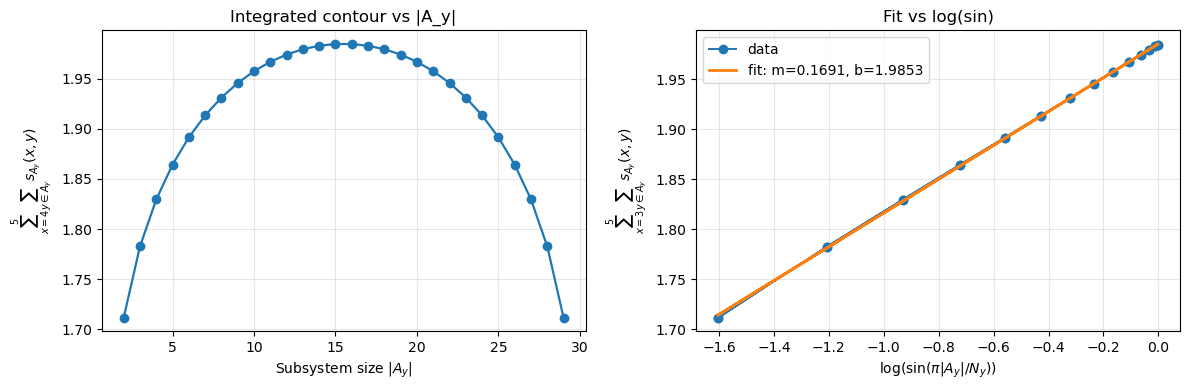

slope = 0.16906372856261806
intercept = 1.9853108486365436
R^2 = 0.9998367786804203
adjusted R^2 = 0.9998305009373596
central charge errror = 1.43824%


In [4]:
# choose x-range to sum over
x0 = model.DW_loc[0]
x_sum_range = np.arange(x0, x0+2)  

# Sum over x=4..5 for each cut
sum_over_x = []
for i, y_cut in enumerate(y_cut_list):
    total = 0.0
    for x in x_sum_range:
        total += Sx_vs_y_cut[x][i]
    sum_over_x.append(total)
Ay = np.array(A_y_list, dtype=float)

yvals = np.array(sum_over_x)

# log-sin x-axis for fit
xvals = np.log(np.sin(np.pi * Ay / Ny))
mask = np.isfinite(xvals)
x_fit = xvals[mask]
y_fit = yvals[mask]

# linear fit
m, b = np.polyfit(x_fit, y_fit, 1)

# R^2 and adjusted R^2
y_pred = m * x_fit + b
ss_res = np.sum((y_fit - y_pred) ** 2)
ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
r2 = 1 - ss_res / ss_tot
n = len(y_fit)
p = 1
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: plain plot vs subsystem size
axes[0].plot(Ay, yvals, marker='o', lw=1.6)
axes[0].set_xlabel(r"Subsystem size $|A_y|$")
axes[0].set_ylabel(r"$\sum_{x=4}^{5}\sum_{y\in A_y} s_{A_y}(x,y)$")
axes[0].set_title("Integrated contour vs |A_y|")
axes[0].grid(alpha=0.3)

# right: fit plot vs log(sin)
axes[1].plot(x_fit, y_fit, marker='o', lw=1.4, label="data")
axes[1].plot(x_fit, y_pred, lw=2, label=f"fit: m={m:.4f}, b={b:.4f}")
axes[1].set_xlabel(r"$\log(\sin(\pi |A_y|/N_y))$")
axes[1].set_ylabel(r"$\sum_{x=3}^{5}\sum_{y\in A_y} s_{A_y}(x,y)$")
axes[1].set_title("Fit vs log(sin)")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.tight_layout()
plt.show()

print(f"slope = {m}")
print(f"intercept = {b}")
print(f"R^2 = {r2}")
print(f"adjusted R^2 = {adj_r2}")
print(f"central charge errror = {np.abs(m-1/6)/(1/6)*100:.6g}%")


{'shape_ok': True, 'Ny': 31, 'shift_max_abs_diff': 9.103828801926284e-15, 'shift_pass': True, 'offdiag_ratio': 1.3118982615312805e-28, 'offdiag_pass': True}


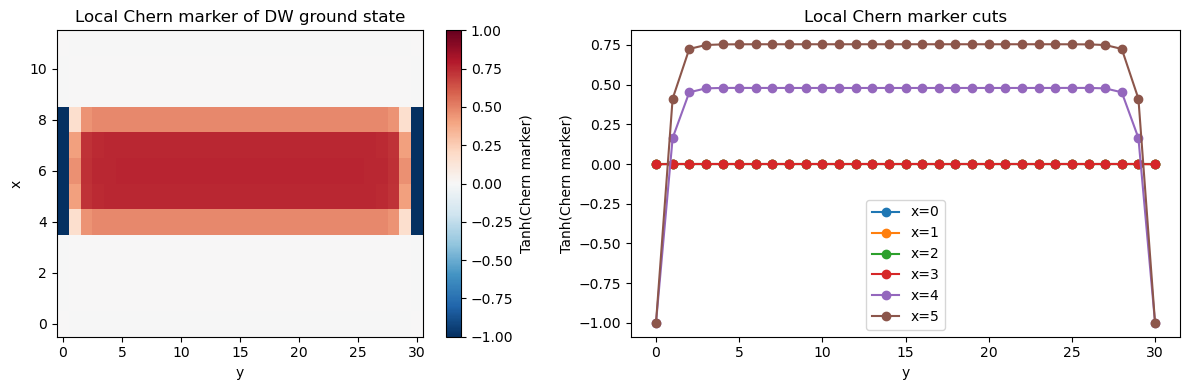

In [5]:

# Local Chern marker to verify DW composition
chern_map = model.local_chern_marker_flat(G_gs, apply_tanh=True)


fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1, 1.2]})

im = axes[0].imshow(chern_map, origin="lower", cmap="RdBu_r", aspect="auto", vmin=-1, vmax=1)
fig.colorbar(im, ax=axes[0], label="Tanh(Chern marker)")
axes[0].set_title("Local Chern marker of DW ground state")
axes[0].set_xlabel("y")
axes[0].set_ylabel("x")

res = model.check_y_translation_invariance(G_gs)
print(res)

for x in range(6):
    axes[1].plot(chern_map[x, :], marker='o', label=f"x={x}")
axes[1].legend()
axes[1].set_title('Local Chern marker cuts')
axes[1].set_xlabel("y")
axes[1].set_ylabel("Tanh(Chern marker)")

plt.tight_layout()
plt.show()


In [6]:
out1 = model.sum_chern_marker_dw_region(G_gs, whole_region=True)
out2 = model.sum_chern_marker_dw_region(G_gs, whole_region=False)
out3 = model.sum_chern_marker_dw_region(G_gs, whole_region_except_bndry=True)

print(f'Chern number (DW_Region) = {out2}')
print(f'Chern number (Whole_Region) = {out1}')
print(f'Chern number (Whole_Region_Except_Boundaries) = {out3}')

Chern number (DW_Region) = -1.5987211554602254e-14
Chern number (Whole_Region) = -1.5987211554602254e-14
Chern number (Whole_Region_Except_Boundaries) = 110.82460893116308


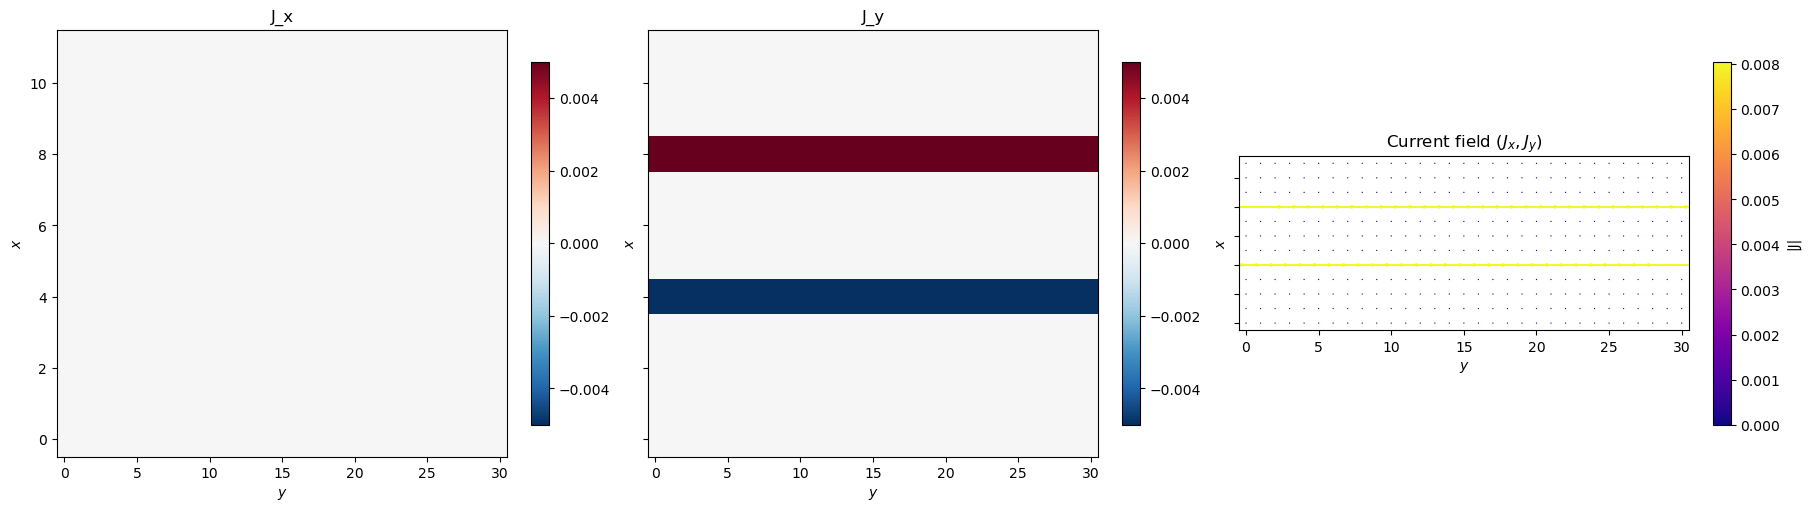

In [7]:

J_x, J_y = model.current_maps_gauge_invariant(G_gs)
fig, axes = model.plot_current_maps(J_x, J_y, figsize=(18, 5), sharey=True, vmin=-0.005, vmax=+0.005)
plt.show()

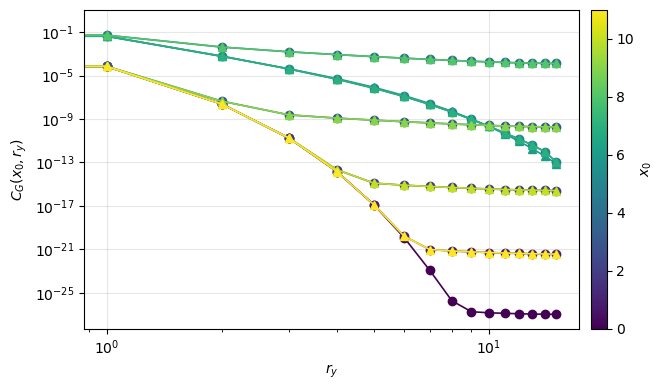

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from fgtn.classA_U1FGTN import classA_U1FGTN
# Top-layer covariance
Nlayer = model.Ntot // 2
if G_gs.shape[0] == model.Ntot:
    G_top = G_gs[:Nlayer, :Nlayer]
elif G_gs.shape[0] == Nlayer:
    G_top = G_gs
else:
    raise ValueError(f"Unexpected G_gs shape: {G_gs.shape}")

# --- Correlation helper (matches plot_corr_y_profiles) ---
G2 = 0.5 * (G_top + np.eye(Nlayer, dtype=np.complex128))
G6 = G2.reshape(2, Nx, Ny, 2, Nx, Ny, order="F")
Gker = np.transpose(G6, (1, 2, 0, 4, 5, 3))  # (x,y,2,x',y',2)

ry_max = Ny // 2
ry_vals = np.arange(0, ry_max + 1, dtype=int)

# --- Plot y-profiles for all x with colorbar ---
fig, ax = plt.subplots(figsize=(7, 4))

cmap = cm.viridis
norm = colors.Normalize(vmin=0, vmax=Nx - 1)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
marker = ['o', '^']
for x0 in range(Nx):
    Gx = Gker[x0, :, :, x0, :, :]  # (Ny,2,Ny,2)
    Y = np.arange(Ny, dtype=np.intp)[:, None]
    Yp = (Y + ry_vals[None, :]) % Ny
    Gx_re = np.transpose(Gx, (0, 2, 1, 3)).reshape(Ny * Ny, 2, 2)
    flat_ix = (Y * Ny + Yp).reshape(-1)
    blocks = Gx_re[flat_ix].reshape(Ny, ry_vals.size, 2, 2)
    C_vec = np.sum(np.abs(blocks) ** 2, axis=(0, 2, 3)) / (2.0 * Ny)
    if x0 < Nx//2:
        ax.plot(ry_vals, C_vec.real, marker=marker[0], lw=1.2, color=cmap(norm(x0)))
    else:
        ax.plot(ry_vals, C_vec.real, marker=marker[1], lw=1.2, color=cmap(norm(x0)))
        
ax.set_xlabel(r"$r_y$")
ax.set_ylabel(r"$C_G(x_0, r_y)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$x_0$")

plt.tight_layout()
plt.show()


------------------------- classA_U1FGTN Initialized -------------------------


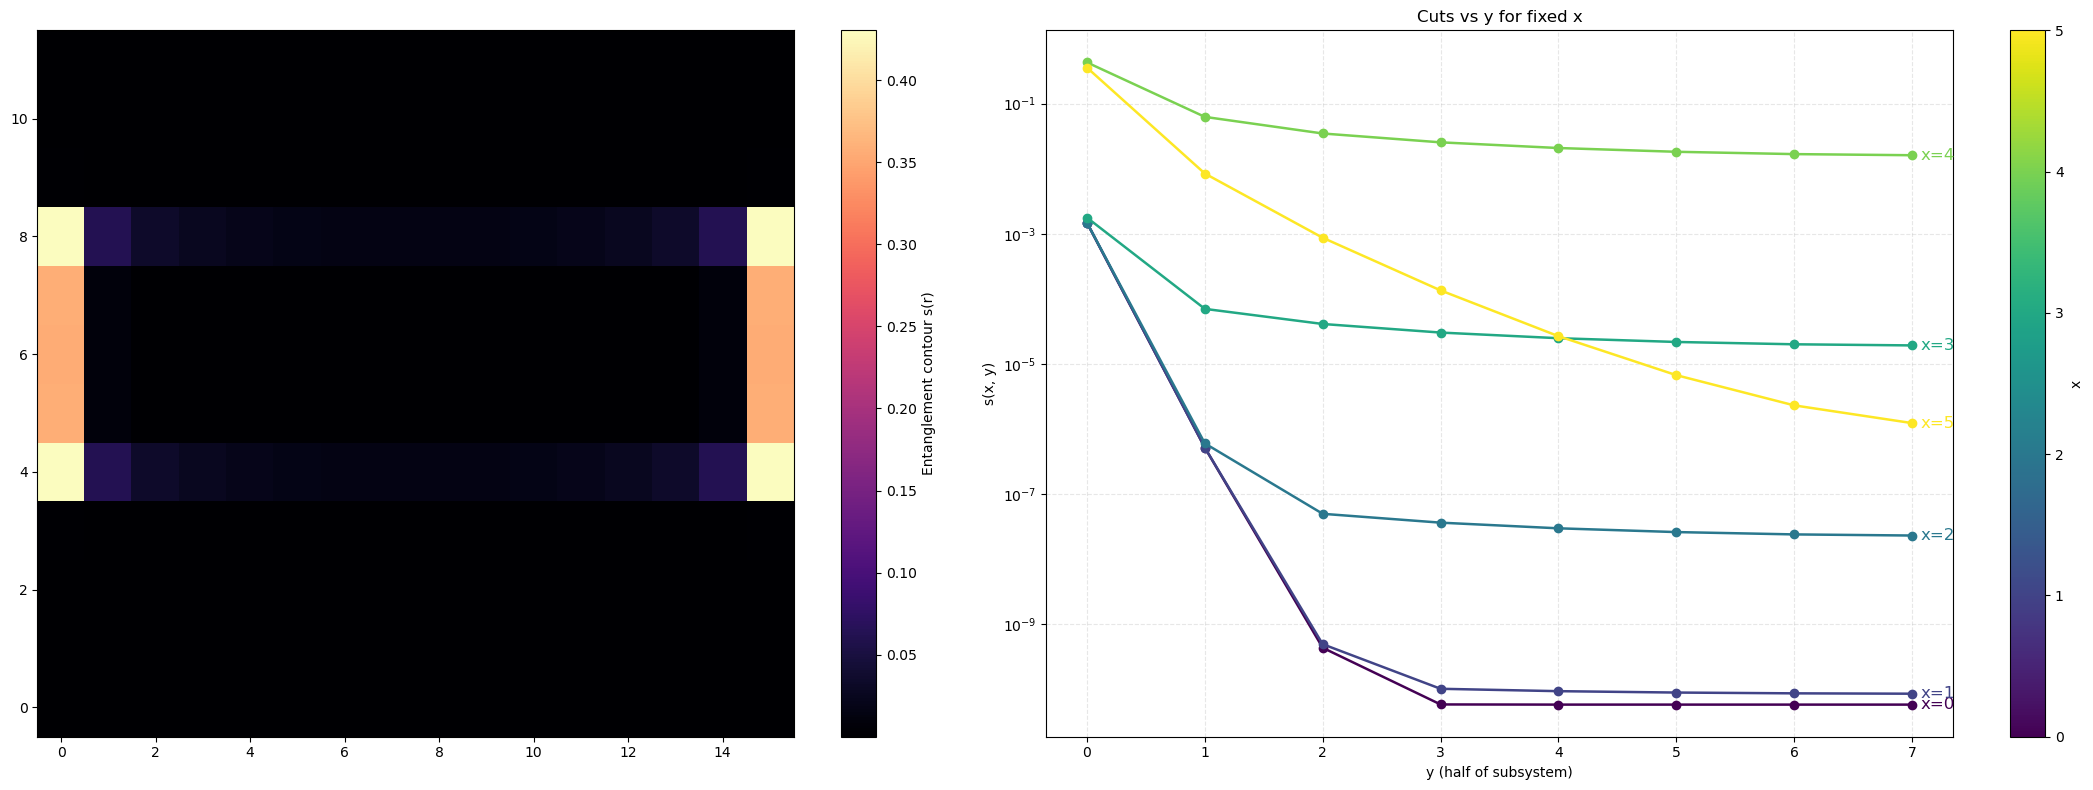

In [9]:
from matplotlib import colors

# --- Entanglement cut at y = Ny//2 (keep upper half; change yA for lower half) ---
y_cut = Ny // 2
yA = np.arange(y_cut, Ny)  # keep y >= Ny//2; use np.arange(0, y_cut) for lower half
xA = np.arange(Nx)

# Build flattened indices i = μ + 2*x + 2*Nx*y for the chosen region
sub_indices = []
for y in yA:
    for x in xA:
        sub_indices.append(0 + 2*x + 2*Nx*y)
        sub_indices.append(1 + 2*x + 2*Nx*y)
sub_indices = np.array(sub_indices, dtype=int)

# Reduced covariance for the subsystem
G_sub = G_gs[np.ix_(sub_indices, sub_indices)]  # shape: (2*Nx*len(yA), 2*Nx*len(yA))

# Entanglement contour on the subsystem.
# Use a helper instance with matching geometry (Nx, Ny_sub=len(yA)).
Ny_sub = len(yA)
contour_helper = classA_U1FGTN(Nx, Ny_sub, DW=False, alpha_1=1, alpha_2=1)
s_map = contour_helper.entanglement_contour(G_sub, len(xA), len(yA))  # shape: (Nx, Ny_sub)

# Plot: heatmap + y-cuts at fixed x with gradient colors
fig, axes = plt.subplots(1, 2, figsize=(22, 8), gridspec_kw={"width_ratios": [1, 1.2]})

# Heatmap
vmin = np.max([np.min(s_map[s_map > 0]), 1e-12])  # avoid zeros
vmax = np.max(s_map)
im2 = axes[0].imshow(
    s_map,
    origin="lower",
    cmap="magma",
    aspect="auto"
)
fig.colorbar(im2, ax=axes[0], label="Entanglement contour s(r)")

# y-cuts at fixed x
y_vals = np.arange(Ny_sub // 2)
x_list = np.arange(Nx//2)  # change to a subset if you want fewer lines
colors = plt.cm.viridis(np.linspace(0, 1, len(x_list)))
markers = ['o', '^']
for x_idx, color in zip(x_list, colors):
    y_curve = s_map[x_idx, :len(y_vals)]
    axes[1].plot(y_vals, y_curve, marker=markers[0], color=color, lw=1.8)
    # Annotate at the last point with a small offset
    x_end = y_vals[-1]
    y_end = y_curve[-1]
    axes[1].annotate(
        f"x={x_idx}",
        xy=(x_end, y_end),
        xytext=(6, 0),
        textcoords="offset points",
        color=color,
        fontsize=12,
        va="center"
    )

axes[1].set_xlabel("y (half of subsystem)")
axes[1].set_ylabel("s(x, y)")
axes[1].set_title("Cuts vs y for fixed x")
axes[1].grid(alpha=0.3, linestyle="--", linewidth=0.8)
axes[1].set_yscale('log')
axes[1].set_xscale('linear')

# Colorbar for x values
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=x_list.min(), vmax=x_list.max()))
sm.set_array([])
fig.colorbar(sm, ax=axes[1], label="x")

plt.tight_layout()
plt.show()


In [10]:
import numpy as np
import matplotlib.pyplot as plt


def compute_modular_hamiltonian(G, eps=1e-12):
    """
    Computes the Modular (Entanglement) Hamiltonian from the covariance matrix.

    Formula: H_mod = ln((1-G)/(1+G)) = -2 * arctanh(G)

    Parameters
    ----------
    G : ndarray
        Top-layer covariance matrix (2C - 1), shape (N, N), N=2*Nx*Ny.
    eps : float
        Clipping parameter to regularize eigenvalues near +/-1.

    Returns
    -------
    H_mod : ndarray
        The single-particle modular Hamiltonian matrix.
    """
    G = np.asarray(G, dtype=np.complex128)
    if G.shape[0] != G.shape[1]:
        raise ValueError("G must be square.")

    evals, evecs = np.linalg.eigh(G)
    evals = np.real_if_close(evals, tol=1e-10)
    evals = np.clip(evals, -1 + eps, 1 - eps)

    h_evals = -2.0 * np.arctanh(evals)
    H_mod = (evecs * h_evals[None, :]) @ evecs.conj().T
    return H_mod


def compute_current_density(H_mod, G, Nx, Ny):
    """
    Computes the current density generated by H_mod in state G.

    Basis assumption (top layer only):
    idx = μ + 2*x + 2*Nx*y, with μ fastest (Fortran order).

    Parameters
    ----------
    H_mod : ndarray
        Modular Hamiltonian matrix, shape (2*Nx*Ny, 2*Nx*Ny).
    G : ndarray
        Covariance matrix (2C - 1), same shape as H_mod.
    Nx, Ny : int
        Lattice dimensions.

    Returns
    -------
    Jx, Jy : ndarray (Ny, Nx)
        Current density along +x and +y bonds, arranged as [y, x].
    """
    Nx = int(Nx)
    Ny = int(Ny)
    Nlayer = 2 * Nx * Ny

    H_mod = np.asarray(H_mod, dtype=np.complex128)
    G = np.asarray(G, dtype=np.complex128)

    if H_mod.shape != (Nlayer, Nlayer) or G.shape != (Nlayer, Nlayer):
        raise ValueError(f"Expected shape ({Nlayer},{Nlayer}) for top-layer input.")

    # Correlation matrix C = (G + I) / 2
    C = 0.5 * (G + np.eye(Nlayer, dtype=np.complex128))

    # Reshape into (x, y, mu, x', y', nu) using Fortran order
    H6 = H_mod.reshape(2, Nx, Ny, 2, Nx, Ny, order="F")
    H6 = np.transpose(H6, (1, 2, 0, 4, 5, 3))  # (Nx,Ny,2,Nx,Ny,2)

    C6 = C.reshape(2, Nx, Ny, 2, Nx, Ny, order="F")
    C6 = np.transpose(C6, (1, 2, 0, 4, 5, 3))  # (Nx,Ny,2,Nx,Ny,2)

    # Neighbor indices
    x_idx = np.arange(Nx)[:, None]
    y_idx = np.arange(Ny)[None, :]
    x_next = (x_idx + 1) % Nx
    y_next = (y_idx + 1) % Ny

    # X-direction current
    Hx = H6[x_idx, y_idx, :, x_next, y_idx, :]  # (Nx,Ny,2,2)
    Cx = C6[x_next, y_idx, :, x_idx, y_idx, :]  # (Nx,Ny,2,2)
    Jx = 2.0 * np.imag(np.sum(Hx * np.swapaxes(Cx, -1, -2), axis=(2, 3)))

    # Y-direction current
    Hy = H6[x_idx, y_idx, :, x_idx, y_next, :]  # (Nx,Ny,2,2)
    Cy = C6[x_idx, y_next, :, x_idx, y_idx, :]  # (Nx,Ny,2,2)
    Jy = 2.0 * np.imag(np.sum(Hy * np.swapaxes(Cy, -1, -2), axis=(2, 3)))

    # Return as (Ny, Nx) for plotting with standard meshgrid
    return Jx.T, Jy.T


def plot_modular_current(Jx, Jy, title="Modular Current"):
    """
    Visualizes the modular current vector field.
    Expects Jx, Jy shaped (Ny, Nx).
    Plots with horizontal axis = y, vertical axis = x.
    """
    Ny, Nx = Jx.shape

    # Transpose so rows -> x, cols -> y
    Jx_plot = Jx.T
    Jy_plot = Jy.T

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

    im0 = axes[0].imshow(Jx_plot, origin="lower", cmap="RdBu_r", aspect="auto")
    axes[0].set_title("Jx")
    axes[0].set_xlabel("y")
    axes[0].set_ylabel("x")
    fig.colorbar(im0, ax=axes[0], label="Jx")

    im1 = axes[1].imshow(Jy_plot, origin="lower", cmap="RdBu_r", aspect="auto")
    axes[1].set_title("Jy")
    axes[1].set_xlabel("y")
    axes[1].set_ylabel("x")
    fig.colorbar(im1, ax=axes[1], label="Jy")


    plt.show()

def plot_modular_quiver(Jx, Jy, title="Modular Current"):
    """
    Quiver-only plot.
    Expects Jx, Jy shaped (Ny, Nx).
    Horizontal axis = y, vertical axis = x.
    """
    Ny, Nx = Jx.shape
    Jx_plot = Jx.T
    Jy_plot = Jy.T

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect("auto")    
    Y, X = np.meshgrid(np.arange(Ny), np.arange(Nx))
    mag = np.sqrt(Jx_plot**2 + Jy_plot**2)

    # Horizontal component is Jy, vertical is Jx with this axis convention.
    q = ax.quiver(Y, X, Jy_plot, Jx_plot, mag, cmap="plasma", pivot="mid")

    ax.set_aspect("auto")
    ax.set_title(title)
    ax.set_xlabel("y")
    ax.set_ylabel("x")
    plt.colorbar(q, ax=ax, label="Current Magnitude")
    plt.show()


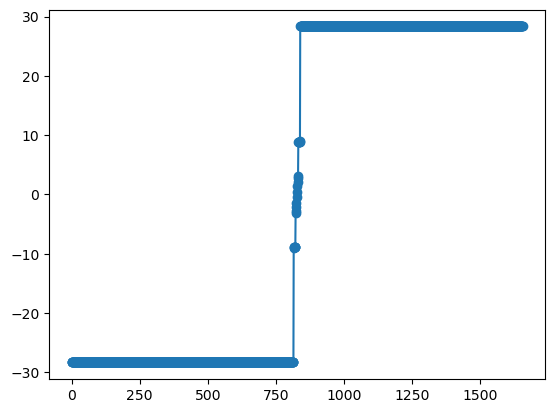

In [20]:
# 1. Get the Entanglement Hamiltonian
# --- Entanglement cut at y = Ny//2 (keep upper half; change yA for lower half) ---
y_cut = 1
yA = np.arange(y_cut, Ny)  # keep y >= Ny//2; use np.arange(0, y_cut) for lower half
xA = np.arange(Nx)

# Build flattened indices i = μ + 2*x + 2*Nx*y for the chosen region
sub_indices = []
for y in yA:
    for x in xA:
        sub_indices.append(0 + 2*x + 2*Nx*y)
        sub_indices.append(1 + 2*x + 2*Nx*y)
sub_indices = np.array(sub_indices, dtype=int)

# Reduced covariance for the subsystem
G_sub = G_gs[np.ix_(sub_indices, sub_indices)]  # shape: (2*Nx*len(yA), 2*Nx*len(yA))

H_mod = compute_modular_hamiltonian(G_sub)
eigvals, eigvecs = np.linalg.eigh(H_mod)
plt.plot(eigvals, marker='o')


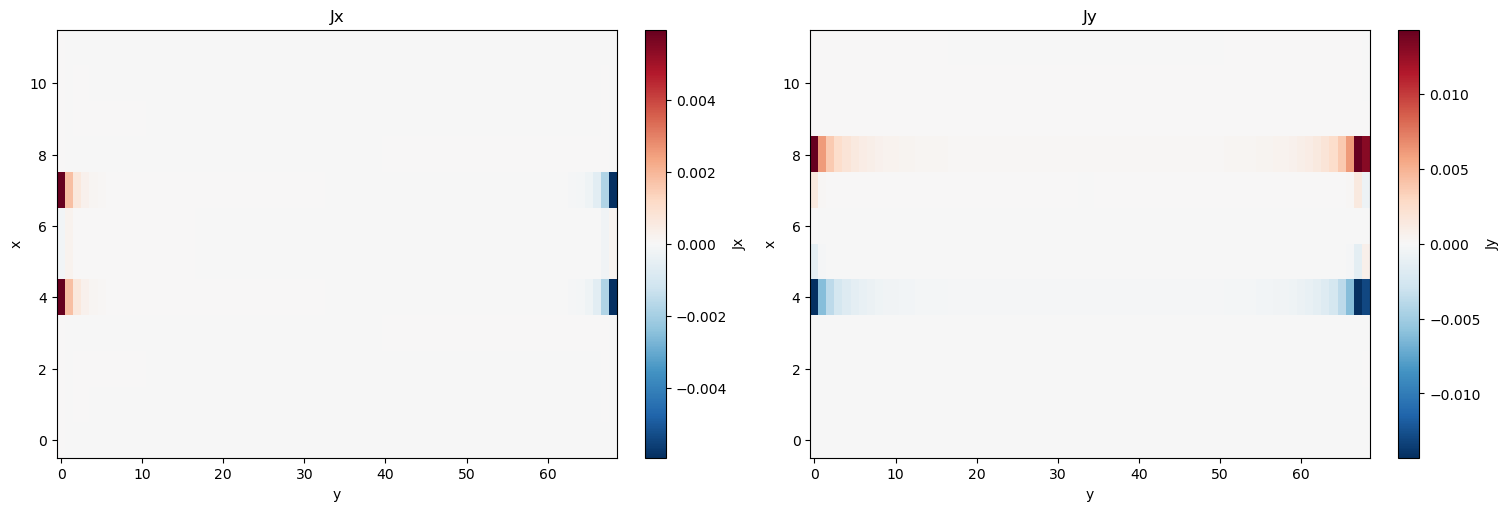

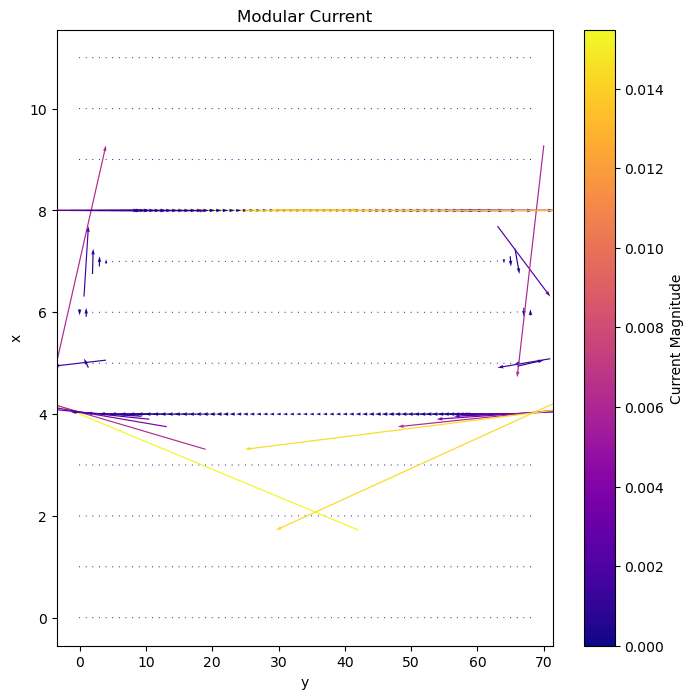

In [21]:
Ny_sub = len(yA)

# 2. Get the Current Flow
Jx, Jy = compute_current_density(H_mod = H_mod, G = G_sub, Nx=Nx, Ny=Ny_sub)

# 3. Visualize
plot_modular_current(Jx, Jy) # (Using the plot function from before)
plot_modular_quiver(Jx, Jy) # (Using the quiver plot function)

slope = 0.00817214, intercept = -0.00122261
R^2 = 0.840342, adjusted R^2 = 0.827037


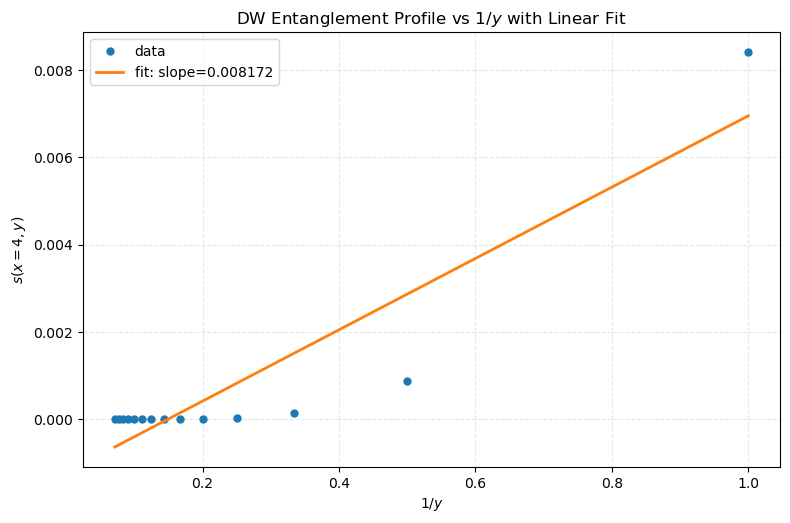

In [73]:
import numpy as np
import matplotlib.pyplot as plt

y_vals = np.arange(1, Ny_sub // 2)
s_curve_dw = s_map[4, int(y_vals[0]):int(y_vals[-1] + 1)]

x = 1.0 / y_vals
y = s_curve_dw

# Fit y = m x + b
m, b = np.polyfit(x, y, 1)
print(f"slope = {m:.6g}, intercept = {b:.6g}")

# R^2 and adjusted R^2
y_hat = m * x + b
ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot
n = len(y)
p = 1  # one predictor
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f"R^2 = {r2:.6g}, adjusted R^2 = {adj_r2:.6g}")

fig, ax = plt.subplots(figsize=(8, 16/3))
ax.plot(x, y, "o", ms=5, label="data")
ax.plot(x, m*x + b, "-", lw=2, label=f"fit: slope={m:.4g}")
ax.set_xlabel(r"$1/y$")
ax.set_ylabel(r"$s(x{=}4,y)$")
ax.set_title(r"DW Entanglement Profile vs $1/y$ with Linear Fit")
ax.grid(alpha=0.3, linestyle="--")
ax.legend()
plt.tight_layout()
plt.show()


In [74]:
import numpy as np
import matplotlib.pyplot as plt
from fgtn.classA_U1FGTN import classA_U1FGTN
# ---- User inputs ----
Nx = 12
Ny_list = 12 * np.arange(1, 13)  # 12, 24, ..., 144
alpha_1, alpha_2 = 30, 1
periodic = True
x_list = np.arange(Nx // 2)
dw_text = f"DWs at x=4, 8"  # <-- fill in with your DW locations
# ---------------------

def entanglement_strip_sums(model, G_gs):
    Ny = model.Ny
    y_cut = Ny // 2
    yA = np.arange(y_cut, Ny)
    xA = np.arange(model.Nx)

    # Build flattened indices i = μ + 2*x + 2*Nx*y
    sub_indices = []
    for y in yA:
        for x in xA:
            sub_indices.append(0 + 2*x + 2*model.Nx*y)
            sub_indices.append(1 + 2*x + 2*model.Nx*y)
    sub_indices = np.array(sub_indices, dtype=int)

    # Reduced covariance
    G_sub = G_gs[np.ix_(sub_indices, sub_indices)]

    # Entanglement contour on the subsystem
    Ny_sub = len(yA)
    contour_helper = classA_U1FGTN(model.Nx, Ny_sub, DW=False, alpha_1=1, alpha_2=1)
    s_map = contour_helper.entanglement_contour(G_sub)  # shape: (Nx, Ny_sub)

    # Sum over y for each fixed x
    Sx = np.sum(s_map[:,], axis=1)  # shape: (Nx,)
    return Sx

# Compute Sx(Ny)
Sx_vs_Ny = {x: [] for x in x_list}

for Ny in Ny_list:
    model = classA_U1FGTN(Nx, Ny, DW=True, alpha_1=alpha_1, alpha_2=alpha_2)
    G_gs = model.G_CI_domain_wall(periodic=periodic)

    Sx = entanglement_strip_sums(model, G_gs)
    for x in x_list:
        Sx_vs_Ny[x].append(Sx[x])

# Plot Sx vs Ny for each x
plt.figure(figsize=(7, 5))
for x in x_list:
    curve = np.array(Sx_vs_Ny[x])
    plt.plot(Ny_list, curve, marker='o', lw=1.5)

    # annotate each curve at the last point
    plt.annotate(
        f"x={x}",
        xy=(Ny_list[-1], curve[-1]),
        xytext=(6, 0),
        textcoords="offset points",
        fontsize=12,
        va="center"
    )

plt.xlabel("Ny")
plt.ylabel("Strip entanglement sum $\\sum_y s(x,y)$")
plt.title("Entanglement contribution per x strip vs Ny")
plt.grid(alpha=0.3)

# textbox for DW locations
plt.gca().text(
    0.02, 0.98, dw_text,
    transform=plt.gca().transAxes,
    va="top", ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="gray")
)

plt.tight_layout()
plt.legend()
plt.show()


DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------


------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 8)
------------------------- classA_U1FGTN Initia

KeyboardInterrupt: 

In [ ]:
x = np.log(Ny_list)
Sx_dw = np.array(Sx_vs_Ny[4])
y = Sx_dw

# Fit y = m x + b
m, b = np.polyfit(x, y, 1)
print(f"slope = {m:.6g}, intercept = {b:.6g}, 1/6={1/6:.6g}")

# R^2 and adjusted R^2
y_hat = m * x + b
ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot
n = len(y)
p = 1  # one predictor
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f"R^2 = {r2:.6g}, adjusted R^2 = {adj_r2:.6g}")

# Plot with fit
fig, ax = plt.subplots(figsize=(8, 16/3))
ax.plot(x, y, "o", label="data", ms=5)
ax.plot(x, m*x + b, "-", label=f"fit: slope={m:.4g}")
ax.set_xlabel(r"$\log(N_y)$")
ax.set_ylabel(r"$\sum_{y} s(x{=}4,y)$")
ax.set_title(r"DW Entanglement entropy vs $\log(N_y)$ with Linear Fit")
ax.grid(alpha=0.3, linestyle="--")
ax.legend()
plt.tight_layout()
plt.show()


NameError: name 'np' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from fgtn.classA_U1FGTN import classA_U1FGTN
# ---- User inputs ----
Nx = 12
Ny_list = 12 * np.arange(1, 13)  # 12, 24, ..., 144
alpha_1, alpha_2 = 30, 1
periodic = True
x_list = np.arange(Nx // 2)
dw_text = "DWs at x=4, 8"
# ---------------------

def entanglement_strip_sums_xpm1(model, G_gs):
    Ny = model.Ny
    y_cut = Ny // 2
    yA = np.arange(y_cut, Ny)
    xA = np.arange(model.Nx)

    # Build flattened indices i = μ + 2*x + 2*Nx*y
    sub_indices = []
    for y in yA:
        for x in xA:
            sub_indices.append(0 + 2*x + 2*model.Nx*y)
            sub_indices.append(1 + 2*x + 2*model.Nx*y)
    sub_indices = np.array(sub_indices, dtype=int)

    # Reduced covariance
    G_sub = G_gs[np.ix_(sub_indices, sub_indices)]

    # Entanglement contour on the subsystem
    Ny_sub = len(yA)
    contour_helper = classA_U1FGTN(model.Nx, Ny_sub, DW=False, alpha_1=1, alpha_2=1)
    s_map = contour_helper.entanglement_contour(G_sub)  # shape: (Nx, Ny_sub)

    # Sum over y for x and x±1
    Sx = np.sum(s_map, axis=1)  # shape: (Nx,)
    Sx_xpm1 = np.zeros_like(Sx)
    for x in range(model.Nx):
        xm1 = (x - 1) % model.Nx
        xp1 = (x + 1) % model.Nx
        Sx_xpm1[x] = Sx[xm1] + Sx[x] + Sx[xp1]

    return Sx_xpm1

# Compute Sx_xpm1(Ny)
Sxpm1_vs_Ny = {x: [] for x in x_list}

for Ny in Ny_list:
    model = classA_U1FGTN(Nx, Ny, DW=True, alpha_1=alpha_1, alpha_2=alpha_2)
    G_gs = model.G_CI_domain_wall(periodic=periodic)

    Sx_xpm1 = entanglement_strip_sums_xpm1(model, G_gs)
    for x in x_list:
        Sxpm1_vs_Ny[x].append(Sx_xpm1[x])

# Plot Sx_xpm1 vs Ny for each x
plt.figure(figsize=(7, 5))
for x in x_list:
    curve = np.array(Sxpm1_vs_Ny[x])
    plt.plot(Ny_list, curve, marker='o', lw=1.5)
    plt.annotate(
        f"x={x}",
        xy=(Ny_list[-1], curve[-1]),
        xytext=(6, 0),
        textcoords="offset points",
        fontsize=12,
        va="center"
    )

plt.xlabel("Ny")
plt.ylabel("Strip entanglement sum $\\sum_y [s(x-1,y)+s(x,y)+s(x+1,y)]$")
plt.title("Entanglement contribution per x±1 strip vs Ny")
plt.grid(alpha=0.3)

plt.gca().text(
    0.02, 0.98, dw_text,
    transform=plt.gca().transAxes,
    va="top", ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="gray")
)

plt.tight_layout()
plt.legend()
plt.show()


DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initia

KeyboardInterrupt: 

DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------
------------------------- classA_U1FGTN Initialized -------------------------


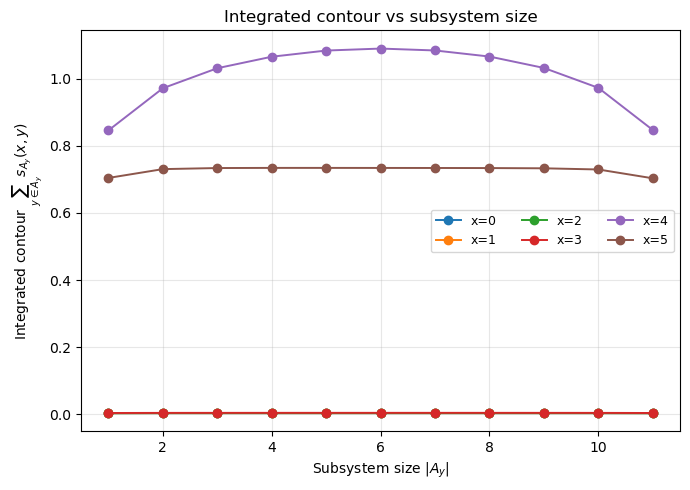

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from fgtn.classA_U1FGTN import classA_U1FGTN
# ---- User inputs ----
Nx, Ny = 12, 12
alpha_1, alpha_2 = 30, 1
periodic = True
x_list = np.arange(Nx // 2)
# ---------------------

def integrated_contour_for_size(model, G_gs, y_cut):
    # Tracing out (y_cut+1)*Nx sites, y_cut in [1, Ny-1])]
    yA = np.arange(y_cut, model.Ny)
    xA = np.arange(model.Nx)

    # Build flattened indices i = μ + 2*x + 2*Nx*y
    sub_indices = []
    for y in yA:
        for x in xA:
            sub_indices.append(0 + 2*x + 2*model.Nx*y)
            sub_indices.append(1 + 2*x + 2*model.Nx*y)
    sub_indices = np.array(sub_indices, dtype=int)

    # Reduced covariance
    G_sub = G_gs[np.ix_(sub_indices, sub_indices)]

    # Entanglement contour on the subsystem
    contour_helper = classA_U1FGTN(model.Nx, len(yA), DW=False, alpha_1=1, alpha_2=1)
    s_map = contour_helper.entanglement_contour(G_sub)  # shape: (Nx, Ay_size)

    # Integrated contour over y for each x
    return np.sum(s_map, axis=1)

# Build model and GS covariance with domain wall
model = classA_U1FGTN(Nx, Ny, DW=True, alpha_1=alpha_1, alpha_2=alpha_2)
G_gs = model.G_CI_domain_wall(periodic=periodic)

# Sweep A_y sizes and collect curves
y_cut_list = np.arange(1, Ny)  # |A_y| from 1..Ny-1
A_y_list = Ny-y_cut_list
Sx_vs_y_cut = {x: [] for x in x_list}

for y_cut in y_cut_list:
    Sx = integrated_contour_for_size(model, G_gs, y_cut)
    for x in x_list:
        Sx_vs_y_cut[x].append(Sx[x])

# Plot: integrated contour vs |A_y| for each x
plt.figure(figsize=(7, 5))
for x in x_list:
    curve = np.array(Sx_vs_y_cut[x])
    plt.plot(A_y_list, curve, marker='o', lw=1.4, label=f"x={x}")

plt.xlabel(r"Subsystem size $|A_y|$")
plt.ylabel(r"Integrated contour $\sum_{y \in A_y} s_{A_y}(x,y)$")
plt.title("Integrated contour vs subsystem size")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend(ncol=3, fontsize=9)
plt.show()


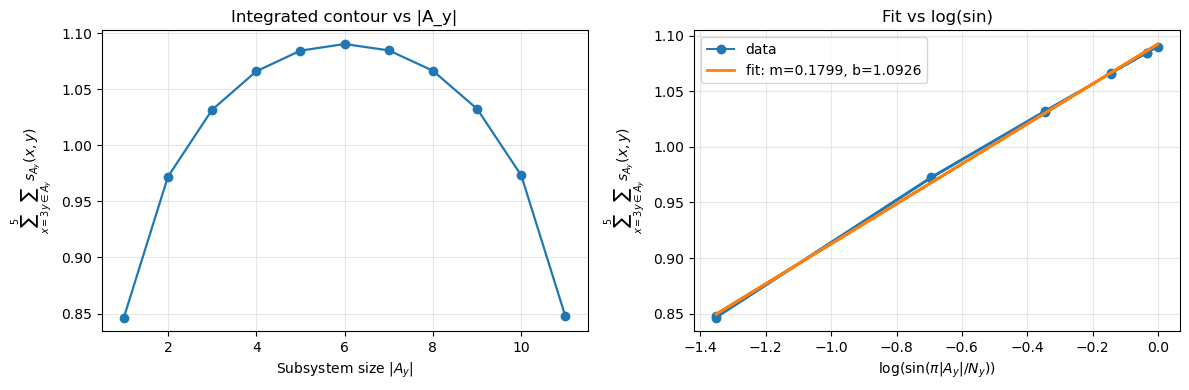

slope = 0.1798728047581122
intercept = 1.0926409489972326
R^2 = 0.999026106480911
adjusted R^2 = 0.998917896089901
central charge errror = 7.92368%


In [58]:
# choose x-range to sum over
x_sum_range = np.arange(4, 5)  

# Sum over x=4..5 for each cut
sum_over_x = []
for i, y_cut in enumerate(y_cut_list):
    total = 0.0
    for x in x_sum_range:
        total += Sx_vs_y_cut[x][i]
    sum_over_x.append(total)
Ay = np.array(A_y_list, dtype=float)

yvals = np.array(sum_over_x)

# log-sin x-axis for fit
xvals = np.log(np.sin(np.pi * Ay / Ny))
mask = np.isfinite(xvals)
x_fit = xvals[mask]
y_fit = yvals[mask]

# linear fit
m, b = np.polyfit(x_fit, y_fit, 1)

# R^2 and adjusted R^2
y_pred = m * x_fit + b
ss_res = np.sum((y_fit - y_pred) ** 2)
ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
r2 = 1 - ss_res / ss_tot
n = len(y_fit)
p = 1
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: plain plot vs subsystem size
axes[0].plot(Ay, yvals, marker='o', lw=1.6)
axes[0].set_xlabel(r"Subsystem size $|A_y|$")
axes[0].set_ylabel(r"$\sum_{x=3}^{5}\sum_{y\in A_y} s_{A_y}(x,y)$")
axes[0].set_title("Integrated contour vs |A_y|")
axes[0].grid(alpha=0.3)

# right: fit plot vs log(sin)
axes[1].plot(x_fit, y_fit, marker='o', lw=1.4, label="data")
axes[1].plot(x_fit, y_pred, lw=2, label=f"fit: m={m:.4f}, b={b:.4f}")
axes[1].set_xlabel(r"$\log(\sin(\pi |A_y|/N_y))$")
axes[1].set_ylabel(r"$\sum_{x=3}^{5}\sum_{y\in A_y} s_{A_y}(x,y)$")
axes[1].set_title("Fit vs log(sin)")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.tight_layout()
plt.show()

print(f"slope = {m}")
print(f"intercept = {b}")
print(f"R^2 = {r2}")
print(f"adjusted R^2 = {adj_r2}")
print(f"central charge errror = {np.abs(m-1/6)/(1/6)*100:.6g}%")


DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------


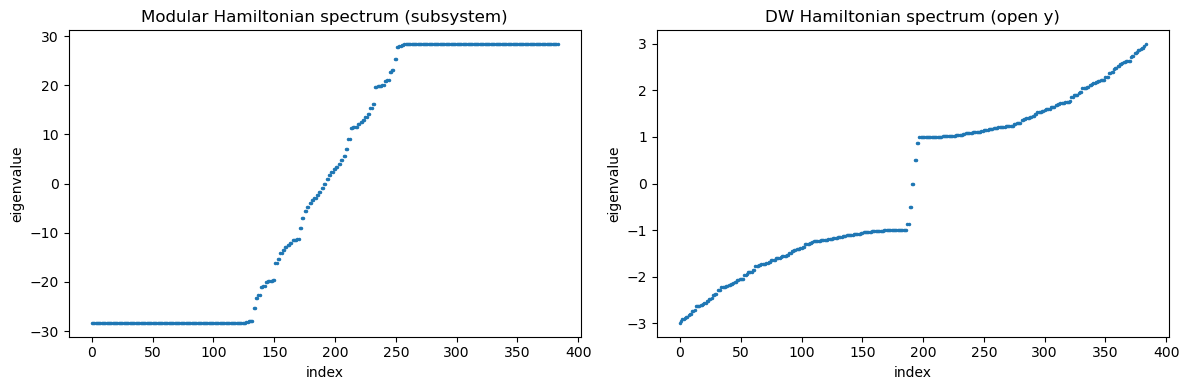

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from fgtn.classA_U1FGTN import classA_U1FGTN
# --- parameters ---
Nx = 12
Ny = 31
y_cut = Ny // 2
Ny_sub = Ny - y_cut

# --- exact DW ground-state covariance (periodic x/y) ---
model = classA_U1FGTN(Nx, Ny, nshell=None, DW=True, alpha_1=1, alpha_2=1)
G_full = model.G_CI_domain_wall(periodic=True)  # exact DW GS covariance

# --- subsystem indices: keep y >= y_cut ---
def build_sub_indices(Nx, Ny, y_cut):
    yA = np.arange(y_cut, Ny)
    sub_indices = []
    for y in yA:
        base = 2 * Nx * y
        for x in range(Nx):
            sub_indices.append(base + 2 * x)
            sub_indices.append(base + 2 * x + 1)
    return np.array(sub_indices, dtype=int)

sub_idx = build_sub_indices(Nx, Ny, y_cut)
G_sub = G_full[np.ix_(sub_idx, sub_idx)]

# --- modular Hamiltonian from covariance ---
def compute_modular_hamiltonian(G, eps=1e-12):
    G = np.asarray(G, dtype=np.complex128)
    evals, evecs = np.linalg.eigh(G)
    evals = np.real_if_close(evals, tol=1e-10)
    evals = np.clip(evals, -1 + eps, 1 - eps)
    h_evals = -2.0 * np.arctanh(evals)
    return (evecs * h_evals[None, :]) @ evecs.conj().T

H_mod = compute_modular_hamiltonian(G_sub)

# --- DW Hamiltonian with periodic x, open y ---
def dw_hamiltonian_open_y(model_obj):
    """
    Same as classA_U1FGTN._domain_wall_hamiltonian but with periodic x and open y.
    """
    if not hasattr(model_obj, "alpha_profile"):
        model_obj.create_domain_wall(alpha_1=model_obj.alpha_1, alpha_2=model_obj.alpha_2)
    alpha = model_obj.alpha_profile

    Nx, Ny = model_obj.Nx, model_obj.Ny
    N = 2 * Nx * Ny
    H = np.zeros((N, N), dtype=np.complex128)

    sigma_x = np.array([[0, 1], [1, 0]], dtype=np.complex128)
    sigma_y = np.array([[0, -1j], [1j, 0]], dtype=np.complex128)
    sigma_z = np.array([[1, 0], [0, -1]], dtype=np.complex128)

    def idx(mu, x, y):
        return mu + 2 * x + 2 * Nx * y

    def add_block(x0, y0, x1, y1, block):
        i0 = [idx(mu, x0, y0) for mu in (0, 1)]
        i1 = [idx(mu, x1, y1) for mu in (0, 1)]
        H[np.ix_(i0, i1)] += block

    # onsite mass terms
    for x in range(Nx):
        for y in range(Ny):
            add_block(x, y, x, y, alpha[x, y] * sigma_z)

    # nearest-neighbor hoppings
    hop_x = -0.5 * sigma_z - 0.5j * sigma_x
    hop_y = -0.5 * sigma_z - 0.5j * sigma_y

    for x in range(Nx):
        for y in range(Ny):
            xp = x + 1
            if xp < Nx:
                add_block(x, y, xp, y, hop_x)
                add_block(xp, y, x, y, hop_x.conj().T)
            else:
                # periodic x
                xp = 0
                add_block(x, y, xp, y, hop_x)
                add_block(xp, y, x, y, hop_x.conj().T)

            yp = y + 1
            if yp < Ny:
                add_block(x, y, x, yp, hop_y)
                add_block(x, yp, x, y, hop_y.conj().T)
            # open y -> no wrap

    return H

# build DW Hamiltonian for subsystem size (Nx, Ny_sub), open in y
model_sub = classA_U1FGTN(Nx, Ny_sub, nshell=None, DW=True, alpha_1=1, alpha_2=1)
H_dw = dw_hamiltonian_open_y(model_sub)

# --- spectra ---
evals_mod = np.linalg.eigvalsh(H_mod)
evals_dw = np.linalg.eigvalsh(H_dw)

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(evals_mod, ".", ms=3)
axes[0].set_title("Modular Hamiltonian spectrum (subsystem)")
axes[0].set_xlabel("index")
axes[0].set_ylabel("eigenvalue")

axes[1].plot(evals_dw, ".", ms=3)
axes[1].set_title("DW Hamiltonian spectrum (open y)")
axes[1].set_xlabel("index")
axes[1].set_ylabel("eigenvalue")

plt.tight_layout()
plt.show()
